In [123]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import pandas as pd
from scipy.optimize import curve_fit



In [124]:
name = 'hcircpgd'
path = f'/home/kale-chen/Documents/PET/TPPT2026/data/{name}.bin'
num_cols, data_size = 4, 2
num_rows = os.path.getsize(path) // (num_cols * data_size)
data1 = np.memmap(path, dtype = np.int16, mode = 'r', shape = (num_rows, num_cols))
eventcounts = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data1[i:i+1000000]
    if num_cols == 3:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    elif num_cols == 6:
        idls = np.asarray(chunk[:, 1], dtype = np.int32)
        idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    elif num_cols == 4:
        idls = np.asarray(chunk[:, 0], dtype = np.int32)
        idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    np.add.at(eventcounts, (idls, idrs), 1)
geomsensitivity = np.fromfile('geomsensitivity.bin', dtype = np.float32).reshape((3072, 3072))
acceptancetable = np.fromfile('acceptancetable.bin', dtype = np.bool).reshape((3072, 3072))
eventcounts = eventcounts * acceptancetable
geomsensitivity = geomsensitivity * acceptancetable
k = np.sum(eventcounts) / np.sum(geomsensitivity)
print(np.sum(eventcounts), np.sum(geomsensitivity), np.sum(acceptancetable), k)
eventcounts /= k
eventcountsL = eventcounts.sum(axis = 0)
eventcountsR = eventcounts.sum(axis = 1)


Event counts: 100%|██████████| 20/20 [00:01<00:00, 18.59it/s]


1.9704008e+07 9.437184e+06 9437184 2.0879118


In [125]:
# Treatment for dead channels, exclude from normalization
deadchannels = 0
for i in range(3072):
    if eventcounts[i, :].sum() == 0:
        deadchannels += 1
        acceptancetable[i, :] = False
for i in range(3072):
    if eventcounts[:, i].sum() == 0:
        deadchannels += 1
        acceptancetable[:, i] = False
print(deadchannels)

7


In [65]:
def histeventcounts(normfactorsL = np.ones(3072), normfactorsR = np.ones(3072)):
    bins = np.linspace(0.8, 1.2, 200)
    bincenters = (bins[:-1] + bins[1:]) / 2
    mask = acceptancetable & (geomsensitivity > 0)

    counts = np.zeros_like(eventcounts, dtype=np.float32)
    counts[mask] = eventcounts[mask] / geomsensitivity[mask]
    countsL = counts.sum(axis = 1)
    countsR = counts.sum(axis = 0)
    geomsL = np.count_nonzero(geomsensitivity, axis=1)
    geomsR = np.count_nonzero(geomsensitivity, axis=0)
    plt.figure(1, figsize = (6, 3))
    plt.hist(countsL / normfactorsL / geomsL, bins = bins, alpha = 0.5, color = 'blue')
    plt.hist(countsR / normfactorsR / geomsR, bins = bins, alpha = 0.5, color = 'red')
    plt.xlim(0.8, 1.2)
    plt.show()

In [126]:
numiterations = 20
alpha = 0.5
currentL = np.ones(3072, dtype = np.float32)
currentR = np.ones(3072, dtype = np.float32)
for iteration in range(numiterations):
    # left
    for i in tqdm(range(3072)):
        observedL = np.sum(eventcounts[i, :] * acceptancetable[i, :])
        predictedL = np.sum(geomsensitivity[i, :] * currentL[i] * currentR * acceptancetable[i, :])
        if observedL > 0 and predictedL > 0:
            ratioL = observedL / predictedL
            currentL[i] = currentL[i] * (ratioL ** alpha)

    # right
    for i in tqdm(range(3072)):
        observedR = np.sum(eventcounts[:, i] * acceptancetable[:, i])
        predictedR = np.sum(geomsensitivity[:, i] * currentL * currentR[i] * acceptancetable[:, i])
        if observedR > 0 and predictedR > 0:
            ratioR = observedR / predictedR
            currentR[i] = currentR[i] * (ratioR ** alpha)
    scale = np.sqrt(np.mean(currentL) / np.mean(currentR))
    currentL /= scale
    currentR *= scale
    print(currentL[0:10])
    print(currentR[0:10])
    currentL.tofile(f'normfactors/it{iteration}L.bin')
    currentR.tofile(f'normfactors/it{iteration}R.bin')
    

100%|██████████| 3072/3072 [00:00<00:00, 19088.74it/s]


[1.0157279  1.0144944  1.0093046  1.017425   1.0236329  1.0387626
 0.99130344 1.0127976  1.0201353  1.0004123 ]
[0.99055696 0.99699605 1.0040245  0.98822236 1.0007937  1.0005898
 0.99711293 0.9865418  1.0003787  0.99549097]


100%|██████████| 3072/3072 [00:00<00:00, 20487.97it/s]


[1.0229954 1.0211331 1.0133742 1.0255797 1.0349764 1.0580125 0.9863145
 1.0186363 1.0296916 1.0000073]
[0.9860683  0.9957287  1.0062885  0.98257804 1.0015851  1.0011797
 0.99607    0.98002386 1.0007883  0.9935848 ]


100%|██████████| 3072/3072 [00:00<00:00, 20839.51it/s]


...

[1.0299665  1.0275433  1.0173664  1.0334853  1.0462883  1.077416
 0.9811691  1.0242919  1.0391165  0.99955076]
[0.98236716 0.99536985 1.0095654  0.977718   1.0037236  1.0028697
 0.9963747  0.9742036  1.0020887  0.99291587]


100%|██████████| 3072/3072 [00:00<00:00, 20940.20it/s]


[1.0299665  1.0275433  1.0173664  1.0334853  1.0462883  1.077416
 0.9811691  1.0242919  1.0391165  0.99955076]
[0.98236716 0.99536985 1.0095654  0.977718   1.0037236  1.0028697
 0.9963747  0.9742036  1.0020887  0.99291587]


100%|██████████| 3072/3072 [00:00<00:00, 21070.25it/s]

[1.0299665  1.0275433  1.0173664  1.0334853  1.0462883  1.077416
 0.9811691  1.0242919  1.0391165  0.99955076]
[0.98236716 0.99536985 1.0095654  0.977718   1.0037236  1.0028697
 0.9963747  0.9742036  1.0020887  0.99291587]


In [11]:
normfactorsL = np.fromfile('normfactors/it4L.bin', dtype = np.float32)
normfactorsR = np.fromfile('normfactors/it4R.bin', dtype = np.float32)
print(normfactorsL[0:10])
print(normfactorsR[0:10])
print(np.mean(normfactorsL), np.mean(normfactorsR))
lorfactors = np.zeros((3072, 3072), dtype = np.float32)
for i in range(3072):
    lorfactors[i, :] = normfactorsL[i] * normfactorsR
print(np.mean(lorfactors))


[1.0188078 1.0159053 1.0145539 1.030016  1.0287645 1.0728899 0.9593214
 1.02078   1.0372089 0.983869 ]
[0.9747067  0.9847722  0.99241734 0.973012   0.9841332  0.9857276
 0.97436    0.9699235  0.992454   0.97416794]
1.0004678 1.0004678
1.0009359


3072 3072
681.0 693.0


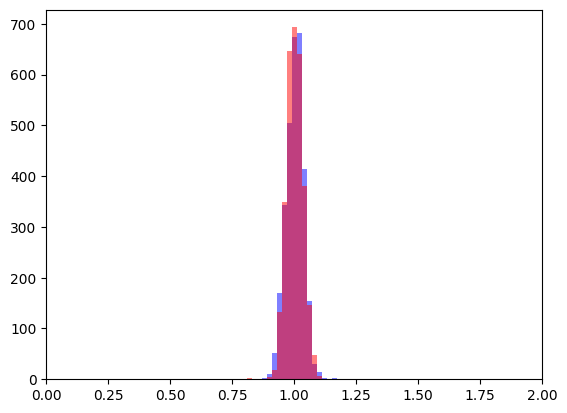

In [114]:
print(np.count_nonzero(currentL), np.count_nonzero(currentR))
hist1, bins = plt.hist(currentL, bins = np.linspace(0, 2, 100), color = 'blue', alpha = 0.5)[0:2]
hist2, bins = plt.hist(currentR, bins = np.linspace(0, 2, 100), color = 'red', alpha = 0.5)[0:2]
print(np.max(hist1), np.max(hist2))
plt.xlim(0, 2)
plt.show()

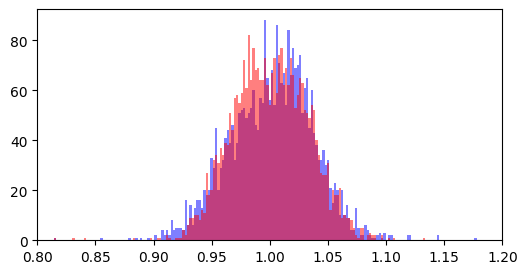

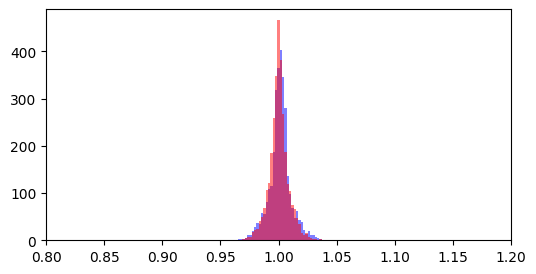

In [84]:
histeventcounts()
histeventcounts(currentL, currentR)

In [10]:
# Construct g_detector estimate
def distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', header = None)
map = mapdf.to_numpy()[:, 0:3]
gdetector = np.zeros((3072, 3072), dtype = np.float32)
for i in tqdm(range(3072)):
    for j in range(3072):
        gdetector[i, j] = distance(map[i + 3072, 0], map[i + 3072, 1], map[j, 0], map[j, 1])**2
gdetector = gdetector / np.mean(gdetector)
gdetector = 1 / gdetector

100%|██████████| 3072/3072 [00:07<00:00, 414.16it/s]


In [127]:
normfactors = np.ones((3072, 3072), dtype = np.float32)
for i in range(3072):
    #normfactors[i, :] = (currentL[i] * currentR) * geomsensitivity[i, :]
    #normfactors[i, :] = 1 / (currentL[i] * currentR) * gdetector[i, :]
    normfactors[i, :] = 1 / (currentL[i] * currentR)
    #normfactors[i, :] = 1
    #normfactors[i, :] = geomsensitivity[i, :]
    #normfactors[i, :] = gdetector[i, :]
normfactors[normfactors == 0] = 1
#normfactors = 1 / normfactors
#normfactors = np.sqrt(normfactors)
normfactors.tofile('normfactors/normfactors.bin')





In [129]:
arr = np.array([[1, 2], [3, 4]])
print(arr.sum(axis = 0))
print(arr.sum(axis = 1))


[4 6]
[3 7]


[3.93699661e+05 9.97498074e-01 4.76146115e-02]


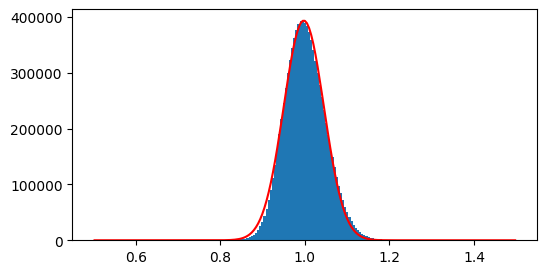

In [86]:
def gaussian(x, a, m, c):
    return a * np.exp(-(x - m) ** 2 / (2 * c ** 2))
plt.figure(1, figsize = (6, 3))
hist, bins = plt.hist(normfactors.flatten(), bins = np.linspace(0.5, 1.5, 200))[0:2]
bincenters = (bins[:-1] + bins[1:]) / 2
popt, _ = curve_fit(gaussian, bincenters, hist, p0 = [np.max(hist), 1, 0.1])
plt.plot(bincenters, gaussian(bincenters, *popt), color = 'red')
print(popt)
plt.show()